## 预测 | 计算指标


Inferencing: 100%|██████████| 5/5 [00:00<00:00, 101.07it/s]

Output range: -0.01 - 1.29
Output range: -0.04 - 1.01
Output range: -0.01 - 1.02
Output range: -0.08 - 1.00
Output range: -0.03 - 1.02



Calculating Metrics: 100%|██████████| 5/5 [00:00<00:00, 107.52it/s]



Average PSNR: 36.2799
Average SSIM: 0.9533
--- PSNR Statistics ---
  Max:     41.0319
  Min:     33.4938
--- SSIM Statistics ---
  Max:     0.9869
  Min:     0.8731

--- Top 4 Best and Worst Cases ---

Top 3 PSNR:
  1: 0002.png (41.0319)
  2: 0001.png (37.4358)
  3: 0005.png (34.8250)
  4: 0004.png (34.6130)

Worst 3 PSNR:
  1: 0003.png (33.4938)
  2: 0004.png (34.6130)
  3: 0005.png (34.8250)
  4: 0001.png (37.4358)

Top 3 SSIM:
  1: 0002.png (0.9869)
  2: 0003.png (0.9734)
  3: 0005.png (0.9704)
  4: 0001.png (0.9626)

Worst 3 SSIM:
  1: 0004.png (0.8731)
  2: 0001.png (0.9626)
  3: 0005.png (0.9704)
  4: 0003.png (0.9734)

--- Displaying Top/Bottom 5 PSNR Images ---


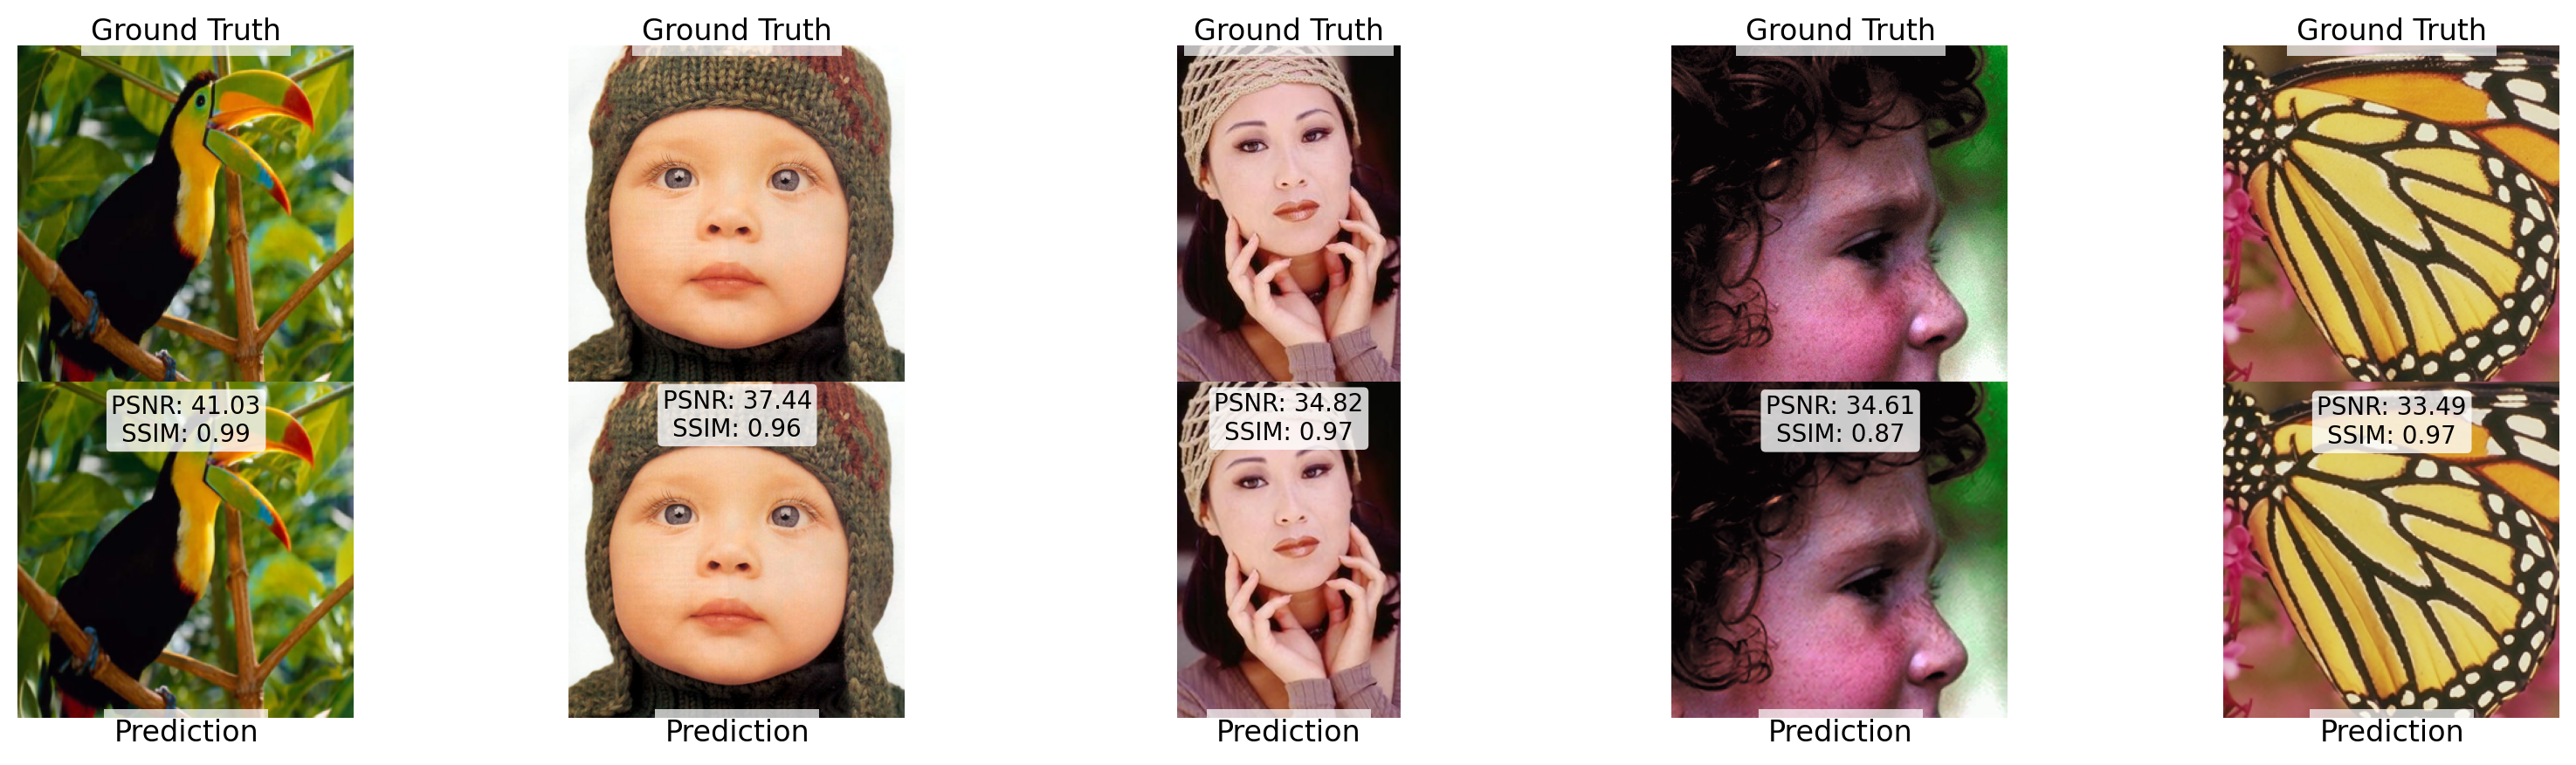


--- Displaying Top/Bottom 5 PSNR Images ---


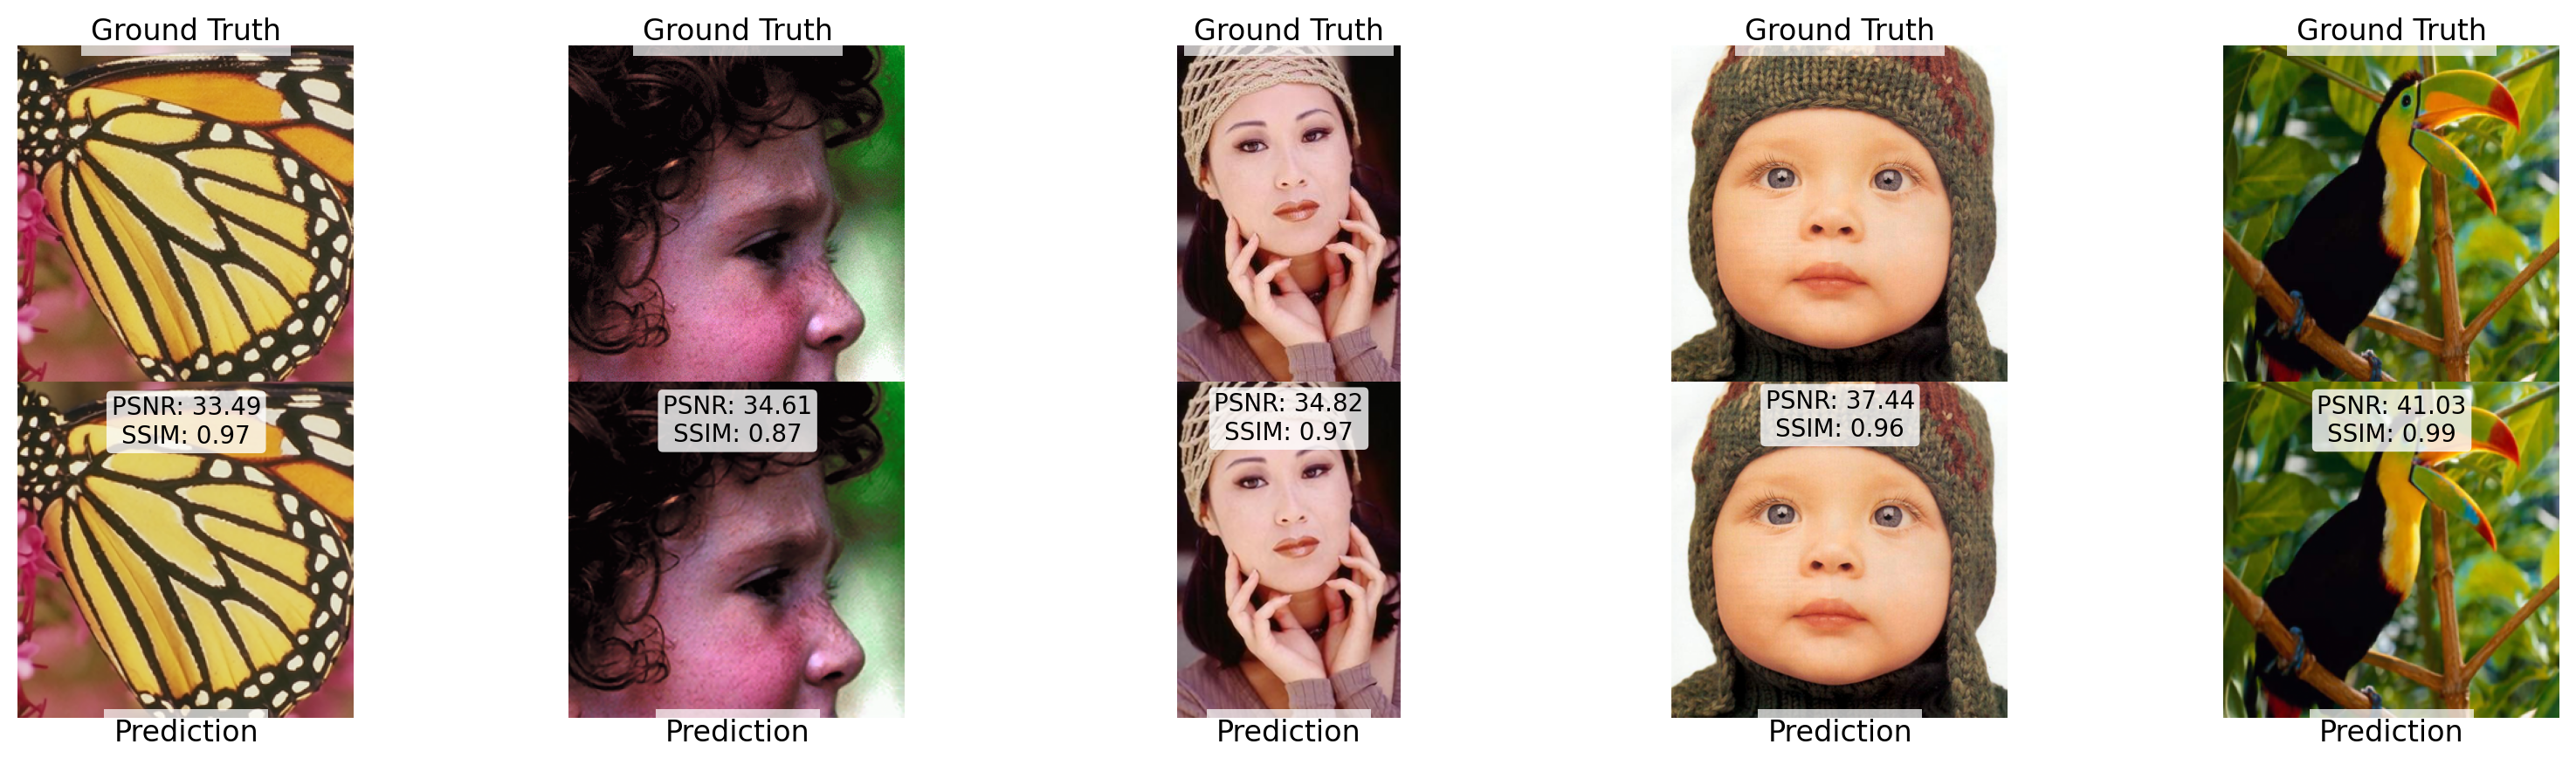

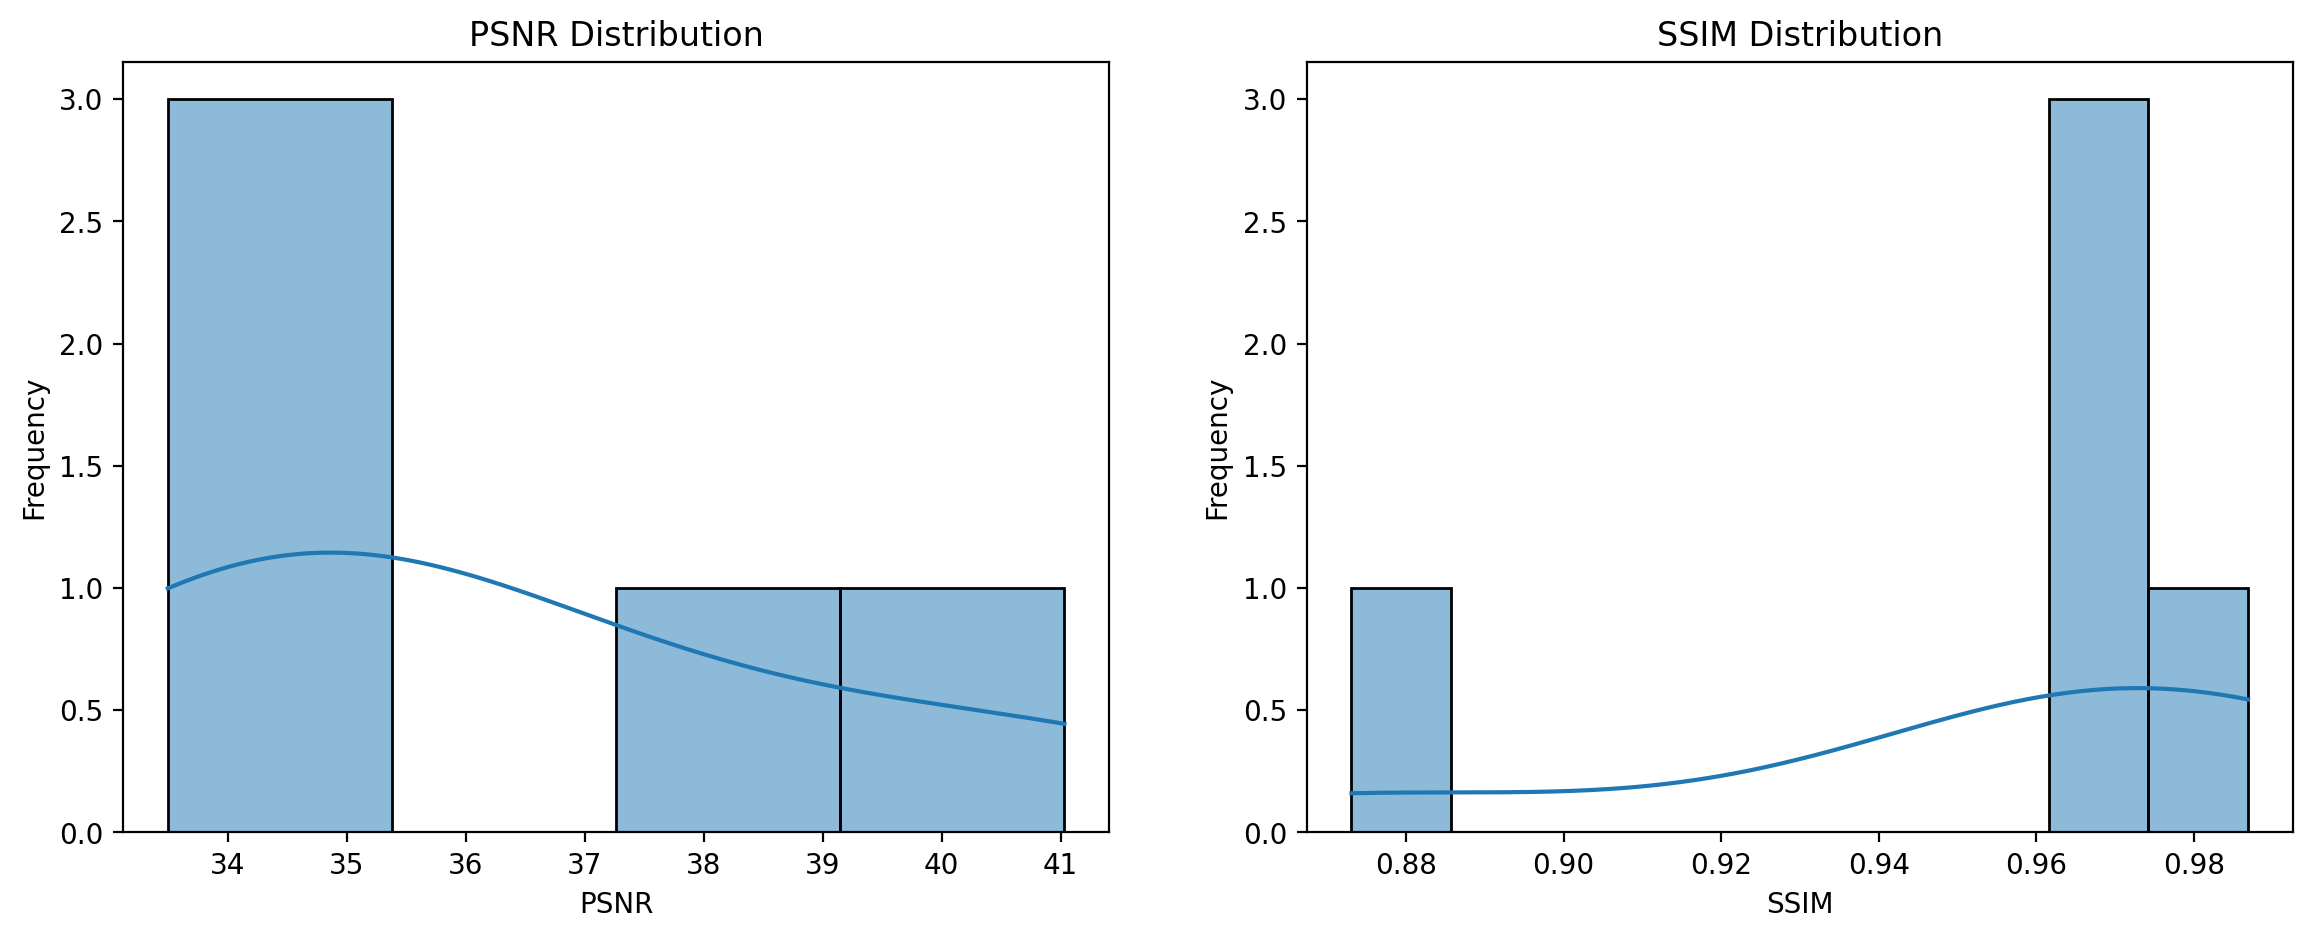

In [5]:
import torch
from tools.utils import infer_from_model
from tools.models.mynet import FusionNet
from tools.models.lkfn import LKFN
from tools.models.efdn import EFDN
from tools.utils import analyze_data, display_top_bottom, plot_histograms
import matplotlib.pyplot as plt


# model = FusionNet(32, 8, 4)
dataset = 'Set5'
model = LKFN()
model_path = "checkpoints/lkfn_myscheduler/last.ckpt"
images_path = f"SR_Test/{dataset}/x2"
output_path = f"SR_Test/{dataset}/PRED_x2"

# 加载模型
ckpt = torch.load(model_path, map_location="cpu", weights_only=False)["state_dict"]
for k in list(ckpt.keys()):
    if k.startswith("model."):
        ckpt[k[6:]] = ckpt[k]
        del ckpt[k]
    else:
        del ckpt[k]
model.load_state_dict(ckpt)
model.load_state_dict(torch.load("checkpoints/epoch_1000.pth"))

# 进行推理, and pass output_path
infer_from_model(model, images_path, output_path, tta=False, num_workers=16)
# Global settings for plot appearance
plt.rcParams["figure.figsize"] = (12, 12)  # Adjust as needed
plt.rcParams["figure.dpi"] = 200


gt_path = f"SR_Test/{dataset}/HR"
pred_path = f"SR_Test/{dataset}/PRED_x2"
num_cols = 5 
valid_results, psnr_values, ssim_values = analyze_data(gt_path, pred_path)
# --- Display Top/Bottom Images ---
display_top_bottom(valid_results, "PSNR", num_cols, reverse_sort=True)  # Top
display_top_bottom(valid_results, "PSNR", num_cols, reverse_sort=False)  # Down


# --- Histograms ---
plot_histograms(psnr_values, ssim_values)


In [4]:
analyze_data(gt_path, pred_path)


Calculating Metrics: 0it [00:00, ?it/s]

No matching images found for evaluation.
